In [ ]:

import pandas as pd
import matplotlib.pyplot as plt

print("Libraries imported successfully!")


Libraries imported successfully!


In [ ]:

url = "https://raw.githubusercontent.com/mwaskom/seaborn-data/master/titanic.csv"

df = pd.read_csv(url)

print("Dataset loaded successfully!")


Dataset loaded successfully!


In [ ]:

df.head()


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [ ]:

print("First 5 rows:")
display(df.head())

print("Last 5 rows:")
display(df.tail())


First 5 rows:


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


Last 5 rows:


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
886,0,2,male,27.0,0,0,13.00,S,Second,man,True,NaN,Southampton,no,True
887,1,1,female,19.0,0,0,30.00,S,First,woman,False,B,Southampton,yes,True
888,0,3,female,NaN,1,2,23.45,S,Third,woman,False,NaN,Southampton,no,False
889,1,1,male,26.0,0,0,30.00,C,First,man,True,C,Cherbourg,yes,True
890,0,3,male,32.0,0,0,7.75,Q,Third,man,True,NaN,Queenstown,no,True


In [ ]:

df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   survived     891 non-null    int64  
 1   pclass       891 non-null    int64  
 2   sex          891 non-null    object 
 3   age          714 non-null    float64
 4   sibsp        891 non-null    int64  
 5   parch        891 non-null    int64  
 6   fare         891 non-null    float64
 7   embarked     889 non-null    object 
 8   class        891 non-null    object 
 9   who          891 non-null    object 
 10  adult_male   891 non-null    bool   
 11  deck         203 non-null    object 
 12  embark_town  889 non-null    object 
 13  alive        891 non-null    object 
 14  alone        891 non-null    bool   
dtypes: bool(2), float64(2), int64(4), object(7)
memory usage: 92.4+ KB


In [ ]:

df.describe()


,survived,pclass,age,sibsp,parch,fare
count,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [ ]:

print("Dataset shape:", df.shape)
print("Column names:", df.columns.tolist())


Dataset shape: (891, 15)
Column names: ['survived', 'pclass', 'sex', 'age', 'sibsp', 'parch', 'fare', 'embarked', 'class', 'who', 'adult_male', 'deck', 'embark_town', 'alive', 'alone']


In [ ]:

print(df.isnull().sum())


survived         0
pclass           0
sex              0
age            177
sibsp            0
parch            0
fare             0
embarked         2
class            0
who              0
adult_male       0
deck           688
embark_town      2
alive            0
alone            0
dtype: int64


In [ ]:

print("Duplicate rows:", df.duplicated().sum())


Duplicate rows: 107


In [ ]:

df_clean = df.copy()

df_clean = df_clean.drop_duplicates()

print("Shape after removing duplicates:", df_clean.shape)


Shape after removing duplicates: (784, 15)


In [ ]:

# 5.3 Fill missing values

# Fill missing age with the median
df_clean["age"] = df_clean["age"].fillna(
    df_clean["age"].median()
)

# Fill missing categorical values only if the columns exist
for col in ["embarked", "embark_town"]:
    if col in df_clean.columns and df_clean[col].isnull().any():
        df_clean[col] = df_clean[col].fillna(
            df_clean[col].mode()[0]
        )

# Drop columns with extensive missing information
df_clean = df_clean.drop(
    columns=["deck", "alive", "who", "adult_male", "class"],
    errors="ignore"
)

# Remove cabin if required
df_clean = df_clean.drop(columns=["cabin"], errors="ignore")

print("Missing values after cleaning:")
print(df_clean.isnull().sum())


Missing values after cleaning:
survived    0
pclass      0
sex         0
age         0
sibsp       0
parch       0
fare        0
embarked    0
alone       0
dtype: int64


In [ ]:

survival_by_sex = df_clean.groupby("sex")["survived"].agg(
    ["count", "sum", "mean"]
)

survival_by_sex.columns = [
    "Total Passengers", "Survivors", "Survival Rate"
]

survival_by_sex["Survival Rate"] *= 100

display(survival_by_sex.round(2))


,Total Passengers,Survivors,Survival Rate
sex,,,
female,293,217,74.06
male,491,106,21.59


In [ ]:

survival_by_class = df_clean.groupby("pclass")["survived"].agg(
    ["count", "sum", "mean"]
)

survival_by_class.columns = [
    "Total Passengers", "Survivors", "Survival Rate"
]

survival_by_class["Survival Rate"] *= 100

display(survival_by_class.round(2))


,Total Passengers,Survivors,Survival Rate
pclass,,,
1,214,135,63.08
2,165,84,50.91
3,405,104,25.68


In [ ]:

age_fare_analysis = df_clean.groupby("survived").agg(
    Average_Age=("age", "mean"),
    Average_Fare=("fare", "mean"),
    Passenger_Count=("survived", "count")
)

display(age_fare_analysis.round(2))


,Average_Age,Average_Fare,Passenger_Count
survived,,,
0,30.56,23.94,461
1,28.35,50.08,323


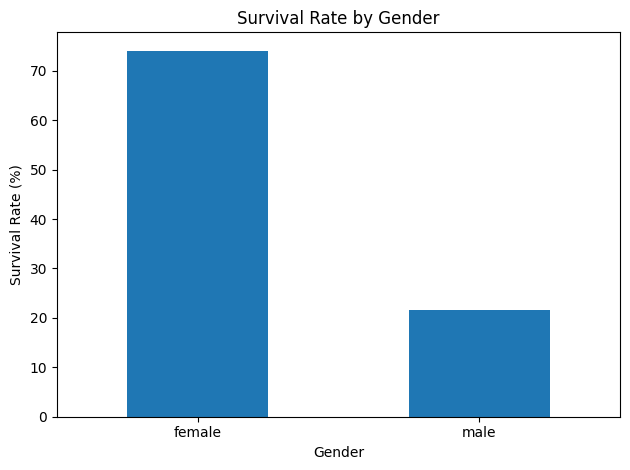

In [ ]:

survival_by_sex["Survival Rate"].plot(
    kind="bar",
    title="Survival Rate by Gender",
    ylabel="Survival Rate (%)",
    xlabel="Gender",
    rot=0
)

plt.tight_layout()
plt.show()


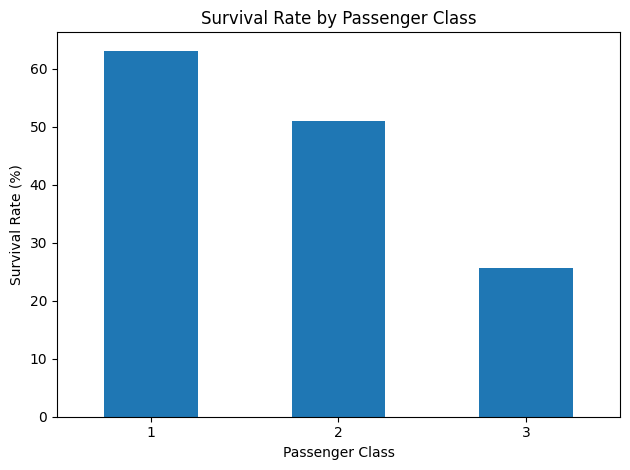

In [ ]:

survival_by_class["Survival Rate"].plot(
    kind="bar",
    title="Survival Rate by Passenger Class",
    ylabel="Survival Rate (%)",
    xlabel="Passenger Class",
    rot=0
)

plt.tight_layout()
plt.show()


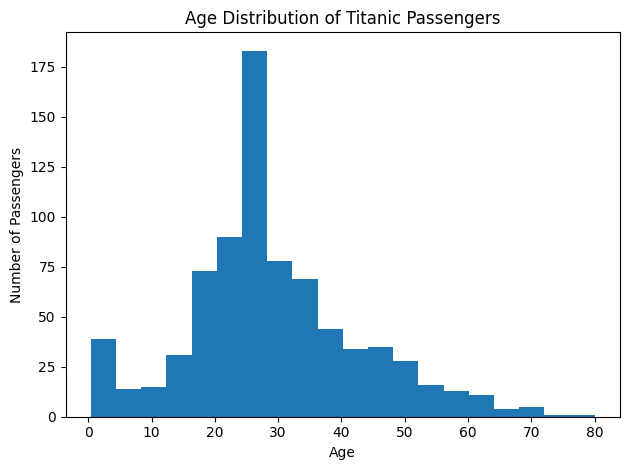

In [ ]:

plt.hist(df_clean["age"], bins=20)
plt.title("Age Distribution of Titanic Passengers")
plt.xlabel("Age")
plt.ylabel("Number of Passengers")
plt.tight_layout()
plt.show()


# Exploratory Data Analysis on Titanic Dataset

## Objective
The objective of this project is to perform Exploratory Data Analysis (EDA) on the Titanic dataset using Python and Pandas to identify patterns, handle missing values and extract useful statistical insights.

## Tools Used
- Python
- Pandas
- Matplotlib
- Google Colab

## Data Cleaning
The dataset was checked for missing values and duplicate rows. Missing age values were filled using the median, while missing categorical values were filled using the mode. Columns with extensive missing data or redundant information were removed where appropriate.

## Key Findings
- Survival rates were compared across genders and more womens survived compared to men.
- Passenger class was analyzed to understand its relationship with survival.Most passengers survived from first class followed by second and then third class.
- Average age and fare were compared between survivors and non-survivors.
- The age distribution of passengers was visualized(Most passangers ranged from age 25 to 30).

## Conclusion
This project provided practical experience with Pandas, data cleaning, statistical analysis, grouping and visualization. EDA helped identify patterns in the Titanic dataset and demonstrated how data analysis can be used to explore real-world datasets.